# Second-model-family matched-information replication

This notebook is a locked Mistral replication on the frozen state bank. Its purpose is cross-family robustness of the matched-information comparison, not discovery of an H1 object.

**Repository framing.** The current paper separates target-specific representation from predictive privilege. A positive neural result is interpreted only after behavioural validity, control, comparator-strength, timing, and information-set checks.


# Second-model-family matched-information replication

## Mistral-7B-Instruct-v0.3 on the frozen 40-game Diplomacy state bank

This notebook is a **locked external-generalization replication** of the final Qwen matched-information experiment. It changes the activation-bearing subject model family while preserving the frozen, outcome-blind Diplomacy state bank, A/B legal-order targets, prompt format, split unit, reader family, text baselines, Brier-score estimand, clustered uncertainty, and native replay checks.

### Primary question
Does a linear pre-action activation reader for a second model family predict that model's consequential focal order better than the strongest validated observer given the **same prompt-visible information**?

### What is deliberately *not* changed
- the source states or order pairs;
- the source-game folds;
- pre-action capture timing;
- deterministic subject decoding;
- the exact-text generative observer contract;
- the trained exact-prompt TF-IDF comparator;
- the structured, constant, and shuffled-label controls;
- the source-game cluster bootstrap and decision rule.

The default second family is `mistralai/Mistral-7B-Instruct-v0.3`. Override only by explicitly setting `LR_P1_SUBJECT_MODEL` before running the notebook; the resolved model revision is frozen into the output manifest.


In [1]:
NOTEBOOK_BUILD = "latent-reservations-p1-second-model-family-matched-information-v1"
print("=" * 104)
print(NOTEBOOK_BUILD)
print("Locked second-model-family replication on the frozen final Diplomacy bank")
print("=" * 104)


latent-reservations-p1-second-model-family-matched-information-v1
Locked second-model-family replication on the frozen final Diplomacy bank


## 1. Dependencies, project paths, and isolated outputs


In [2]:
from __future__ import annotations

import gc
import hashlib
import json
import os
import re
import subprocess
import sys
import zipfile
from datetime import datetime, timezone
from pathlib import Path

subprocess.run([
    sys.executable, "-m", "pip", "install",
    "numpy<2", "pandas>=2,<3", "scikit-learn>=1.4,<2", "scipy>=1.12,<2",
    "safetensors>=0.4", "transformers>=4.45,<5", "accelerate>=0.30,<2",
    "tqdm>=4.66", "matplotlib>=3.8,<4", "sentencepiece>=0.2",
], check=True)

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

PROJECT_ROOT = Path(os.environ.get("LR_PROJECT_ROOT", "/workspace/latent-reservations")).expanduser().resolve()
NOTEBOOK_SLUG = "20_second_model_family_matched_information_replication"
RUN_ID = os.environ.get("LR_P1_RUN_ID", datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ"))
BASE = PROJECT_ROOT / "notebook_outputs" / NOTEBOOK_SLUG
RUN_DIR = BASE / RUN_ID
MANIFEST_DIR = RUN_DIR / "manifests"
DATA_DIR = RUN_DIR / "data"
ACTIVATION_DIR = DATA_DIR / "activations"
RAW_DIR = DATA_DIR / "raw_outputs"
TABLE_DIR = RUN_DIR / "results" / "tables"
FIGURE_DIR = RUN_DIR / "results" / "figures"
CICERO_REPO = PROJECT_ROOT / "vendor" / "diplomacy_cicero"
HF_CACHE_DIR = Path(os.environ.get("LR_HF_CACHE_DIR", os.environ.get("HF_HOME", "/workspace/.cache/huggingface"))).expanduser().resolve()

for path in [MANIFEST_DIR, DATA_DIR, ACTIVATION_DIR, RAW_DIR, TABLE_DIR, FIGURE_DIR]:
    path.mkdir(parents=True, exist_ok=True)
BASE.mkdir(parents=True, exist_ok=True)
(BASE / "latest_run.json").write_text(json.dumps({
    "notebook_slug": NOTEBOOK_SLUG,
    "run_id": RUN_ID,
    "run_output_dir": str(RUN_DIR),
    "updated_at_utc": datetime.now(timezone.utc).isoformat(),
}, indent=2))
print({"project_root": str(PROJECT_ROOT), "run_id": RUN_ID, "run_dir": str(RUN_DIR)})


{'project_root': '/workspace/latent-reservations', 'run_id': '20260816T085737Z', 'run_dir': '/workspace/latent-reservations/notebook_outputs/20_second_model_family_matched_information_replication/20260816T085737Z'}


## 2. Freeze and verify the exact source-state bank

The replication uses the accepted 40-game direct-test state bank created before Qwen outcomes were observed. It deliberately does **not** rerun state selection for the second model.


In [3]:
SOURCE_RUN_ID = os.environ.get("LR_P1_SOURCE_NB19_RUN_ID", "20260815T180359Z")
SOURCE_RUN_DIR = Path(os.environ.get(
    "LR_P1_SOURCE_NB19_RUN_DIR",
    str(PROJECT_ROOT / "notebook_outputs" / "19_cicero_h1_activation_vs_strong_text" / SOURCE_RUN_ID),
)).expanduser().resolve()
EXPECTED_BANK_SHA256 = "e21a88ae614279e2bde67554e8f788d28a7c6891b1ffb5cfd281a3bc23280900"

if not SOURCE_RUN_DIR.exists():
    raise FileNotFoundError(
        f"Accepted source run not found: {SOURCE_RUN_DIR}. Set LR_P1_SOURCE_NB19_RUN_DIR to an exact copy of the accepted run."
    )
source_readiness = json.loads((SOURCE_RUN_DIR / "results" / "tables" / "readiness.json").read_text())
if source_readiness.get("experiment_valid_for_h1_inference") is not True:
    raise RuntimeError("The source Qwen run is not marked valid for H1 inference.")

bank_path = SOURCE_RUN_DIR / "results" / "tables" / "source_state_bank_preoutcome.csv"
bank_sha = hashlib.sha256(bank_path.read_bytes()).hexdigest()
if bank_sha != EXPECTED_BANK_SHA256:
    raise RuntimeError(f"Frozen state-bank hash mismatch: {bank_sha}")
state_bank_df = pd.read_csv(bank_path)
state_dir = SOURCE_RUN_DIR / "data" / "states"
state_files = {p.stem: p for p in state_dir.glob("*.json")}
selected_states = []
for state_id in state_bank_df["state_id"].astype(str).tolist():
    path = state_files.get(state_id)
    if path is None:
        raise FileNotFoundError(f"Missing frozen state JSON: {state_id}")
    selected_states.append(json.loads(path.read_text()))

if len(selected_states) != len(state_bank_df):
    raise RuntimeError("State-bank row/JSON count mismatch.")
for row, state in zip(state_bank_df.to_dict("records"), selected_states):
    for key in ["state_id", "game_index", "fold", "phase_name", "power", "option_a", "option_b", "parent_game_sha256"]:
        if str(state[key]) != str(row[key]):
            raise RuntimeError(f"Frozen state mismatch for {state['state_id']} / {key}")

print({
    "source_run": str(SOURCE_RUN_DIR),
    "state_bank_sha256": bank_sha,
    "states": len(selected_states),
    "source_games": int(state_bank_df["game_index"].nunique()),
})


{'source_run': '/workspace/latent-reservations/notebook_outputs/19_cicero_h1_activation_vs_strong_text/20260815T180359Z', 'state_bank_sha256': 'e21a88ae614279e2bde67554e8f788d28a7c6891b1ffb5cfd281a3bc23280900', 'states': 78, 'source_games': 40}


## 3. Legacy native-engine replay handoff

The modern GPU process never imports the legacy `pydipcc` extension. Native replay is performed in the already-accepted Python 3.7 / PyTorch 1.7.1 CICERO environment through a subprocess.


In [4]:
LEGACY_ENV = PROJECT_ROOT / ".venvs" / "cicero_full_agent_py37_source_v5"
LEGACY_PYTHON = LEGACY_ENV / "bin" / "python"
PYTHON_BASE = PROJECT_ROOT / "vendor" / "cicero_runtime_v5" / "cpython-3.7.17"
if not LEGACY_PYTHON.exists():
    raise FileNotFoundError(f"Accepted legacy CICERO interpreter missing: {LEGACY_PYTHON}")
stack_markers = sorted(LEGACY_ENV.glob(".latent_reservations_cicero_stack_v5_*"))
if not stack_markers:
    raise RuntimeError("Accepted CICERO stack marker is missing; rerun the successful legacy bootstrap first.")
stack_meta = json.loads(stack_markers[-1].read_text())

probe_code = r"""
import json, pathlib, sys
import torch, pybind11
root = pathlib.Path(torch.__file__).resolve().parent
print(json.dumps({
    "python": sys.executable, "torch": torch.__version__,
    "torch_cmake_prefix": str(torch.utils.cmake_prefix_path), "torch_lib": str(root / "lib"),
    "pybind11_cmake_dir": pybind11.get_cmake_dir(),
}))
"""
probe = subprocess.run([str(LEGACY_PYTHON), "-c", probe_code], cwd=CICERO_REPO, text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
if probe.returncode != 0:
    raise RuntimeError(probe.stdout)
legacy_probe = json.loads(probe.stdout.strip().splitlines()[-1])
legacy_engine_env = os.environ.copy()
for key in ["PYTHONPATH", "PYTHONHOME", "CMAKE_TOOLCHAIN_FILE", "CMAKE_C_COMPILER", "CMAKE_CXX_COMPILER"]:
    legacy_engine_env.pop(key, None)
legacy_engine_env["PATH"] = str(LEGACY_ENV / "bin") + os.pathsep + legacy_engine_env.get("PATH", "")
legacy_engine_env["PYTHON"] = str(LEGACY_PYTHON)
legacy_engine_env["PYTHON_EXECUTABLE"] = str(LEGACY_PYTHON)
legacy_engine_env["VIRTUAL_ENV"] = str(LEGACY_ENV)
legacy_engine_env["PYTHONNOUSERSITE"] = "1"
legacy_engine_env["PYBIND11_CMAKE_DIR"] = str(legacy_probe["pybind11_cmake_dir"])
legacy_engine_env["CMAKE_PREFIX_PATH"] = os.pathsep.join([str(legacy_probe["pybind11_cmake_dir"]), str(legacy_probe["torch_cmake_prefix"]), str(LEGACY_ENV), str(PYTHON_BASE)])
legacy_engine_env["CMAKE_LIBRARY_PATH"] = os.pathsep.join([str(legacy_probe["torch_lib"]), str(LEGACY_ENV / "lib"), str(PYTHON_BASE / "lib")])
legacy_engine_env["LD_LIBRARY_PATH"] = os.pathsep.join([str(legacy_probe["torch_lib"]), str(LEGACY_ENV / "lib"), str(PYTHON_BASE / "lib"), legacy_engine_env.get("LD_LIBRARY_PATH", "")])
if stack_meta.get("cxxflags"):
    legacy_engine_env["CXXFLAGS"] = str(stack_meta["cxxflags"])

import_probe = subprocess.run([
    str(LEGACY_PYTHON), "-c",
    "import json,torch; from fairdiplomacy import pydipcc; print(json.dumps({'torch':torch.__version__,'pydipcc':pydipcc.__file__,'has_game':hasattr(pydipcc,'Game')}))"
], cwd=CICERO_REPO, env=legacy_engine_env, text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
if import_probe.returncode != 0:
    raise RuntimeError("Legacy pydipcc import failed. Restore the accepted CICERO runtime first.\n" + import_probe.stdout)
legacy_runtime = json.loads(import_probe.stdout.strip().splitlines()[-1])
if not legacy_runtime.get("has_game"):
    raise RuntimeError("Legacy pydipcc imported without Game.")
print(legacy_runtime)


{'torch': '1.7.1+cu110', 'pydipcc': '/workspace/latent-reservations/vendor/diplomacy_cicero/fairdiplomacy/pydipcc.cpython-37m-x86_64-linux-gnu.so', 'has_game': True}


## 4. Predeclared replication protocol


In [5]:
MIN_USABLE_STATES = int(os.environ.get("LR_P1_MIN_USABLE_STATES", "60"))
MIN_SOURCE_GAMES = int(os.environ.get("LR_P1_MIN_SOURCE_GAMES", "30"))
ACTION_VALIDITY_MIN = float(os.environ.get("LR_P1_ACTION_VALIDITY_MIN", "0.95"))
AUDITOR_VALIDITY_MIN = float(os.environ.get("LR_P1_AUDITOR_VALIDITY_MIN", "0.95"))
MIN_EACH_LABEL = int(os.environ.get("LR_P1_MIN_EACH_LABEL", "15"))
ACTION_GENERATION_CEILING = int(os.environ.get("LR_P1_ACTION_TOKEN_CEILING", "4096"))
AUDITOR_GENERATION_CEILING = int(os.environ.get("LR_P1_AUDITOR_TOKEN_CEILING", "1024"))
BOOTSTRAP_REPS = int(os.environ.get("LR_P1_BOOTSTRAP_REPS", "20000"))
SEED = int(os.environ.get("LR_SEED", "20260815"))

SUBJECT_MODEL = os.environ.get("LR_P1_SUBJECT_MODEL", "mistralai/Mistral-7B-Instruct-v0.3")
SUBJECT_REVISION = os.environ.get("LR_P1_SUBJECT_REVISION", "main")
if SUBJECT_MODEL == "Qwen/Qwen2.5-7B-Instruct":
    raise RuntimeError("P1 is a second-family replication; do not set the subject back to the original Qwen checkpoint.")

protocol = {
    "experiment": "second-model-family replication",
    "source_state_bank_sha256": EXPECTED_BANK_SHA256,
    "source_state_count": int(len(selected_states)),
    "source_games": int(state_bank_df["game_index"].nunique()),
    "subject_model": SUBJECT_MODEL,
    "subject_revision_requested": SUBJECT_REVISION,
    "behavioral_target": "model-specific consequential choice of frozen option B versus option A",
    "prompt_format": "identical compact prompt text before chat-template rendering",
    "activation_timing": "final rendered prompt token before any subject output",
    "split_unit": "source game",
    "folds": "frozen source-state folds",
    "activation_reader": "all-layer linear logistic, nested grouped layer and C selection",
    "strong_text_candidates": ["same-model matched generative observer", "trained exact-prompt TF-IDF"],
    "strong_text_selection": "inner grouped folds only",
    "controls": ["structured", "constant", "shuffled-label activation"],
    "primary_metric": "Brier score",
    "primary_effect": "source-game mean squared-error(strong text) - squared-error(activation)",
    "uncertainty": "20,000-replicate source-game cluster bootstrap",
    "support_rule": "valid run AND delta > 0 AND bootstrap CI low > 0 AND activation beats shuffled-label control",
    "no_test_fold_tuning": True,
}
(MANIFEST_DIR / "protocol_freeze.json").write_text(json.dumps(protocol, indent=2))
print(json.dumps(protocol, indent=2))


{
  "experiment": "second-model-family replication",
  "source_state_bank_sha256": "e21a88ae614279e2bde67554e8f788d28a7c6891b1ffb5cfd281a3bc23280900",
  "source_state_count": 78,
  "source_games": 40,
  "subject_model": "mistralai/Mistral-7B-Instruct-v0.3",
  "subject_revision_requested": "main",
  "behavioral_target": "model-specific consequential choice of frozen option B versus option A",
  "prompt_format": "identical compact prompt text before chat-template rendering",
  "activation_timing": "final rendered prompt token before any subject output",
  "split_unit": "source game",
  "folds": "frozen source-state folds",
  "activation_reader": "all-layer linear logistic, nested grouped layer and C selection",
  "strong_text_candidates": [
    "same-model matched generative observer",
    "trained exact-prompt TF-IDF"
  ],
  "strong_text_selection": "inner grouped folds only",
  "controls": [
    "structured",
    "constant",
    "shuffled-label activation"
  ],
  "primary_metric": "Bri

## 5. Exact compact full-press prompt


In [6]:
def render_message_history(state):
    if not state["messages"]:
        return "(none)"
    return "\n".join(
        f"{message['sender']} -> {message['recipient']}: {message['text']}"
        for message in state["messages"]
    )


def render_fixed_own_orders(state):
    if not state["own_nonfocal_fixed_orders"]:
        return "(none)"
    return "\n".join(f"- {order}" for order in state["own_nonfocal_fixed_orders"])


def render_mapping_lines(mapping):
    if not isinstance(mapping, dict) or not mapping:
        return "(none)"
    lines = []
    for key in sorted(mapping, key=str):
        value = mapping[key]
        if isinstance(value, (list, tuple)):
            text = ", ".join(str(item) for item in value) if value else "(none)"
        else:
            text = json.dumps(value, sort_keys=True, ensure_ascii=False)
        lines.append(f"{key}: {text}")
    return "\n".join(lines)


def render_compact_state(state):
    board = state["board_state"]
    sections = [
        ("UNITS", render_mapping_lines(board.get("units", {}))),
        ("SUPPLY CENTERS", render_mapping_lines(board.get("centers", {}))),
        ("HOME CENTERS", render_mapping_lines(board.get("homes", {}))),
        ("RETREATS", render_mapping_lines(board.get("retreats", {}))),
        ("BUILDS", render_mapping_lines(board.get("builds", {}))),
    ]
    board_text = "\n\n".join(f"{title}\n{body}" for title, body in sections)
    return (
        f"You control {state['power']} in full-press Diplomacy.\n"
        f"Movement phase: {state['phase_name']}\n\n"
        + board_text
        + "\n\nYOUR RELEASED PRIVATE BILATERAL MESSAGES\n"
        + render_message_history(state)
        + "\n\nYOUR FIXED NONFOCAL ORDERS FOR THIS REPLAY\n"
        + render_fixed_own_orders(state)
        + "\n\nFOCAL UNIT\n"
        + str(state["focal_location"])
        + "\n\nTWO NATIVE-LEGAL FOCAL ORDERS\n"
        + f"1. {state['option_a']}\n"
        + f"2. {state['option_b']}\n\n"
        + "Other powers' current orders are simultaneous and hidden. "
        + "The released record may omit conversations that were not released. "
        + "Choose only between the two legal orders above."
    )


def subject_action_prompt(state):
    return (
        render_compact_state(state)
        + "\n\n<CONSEQUENTIAL_ORDER_REQUEST>\n"
        + "Choose the focal order you want to submit. "
        + "You may reason privately for as long as useful. "
        + "When finished, end with exactly one of the two legal order strings inside <ORDER>...</ORDER>.\n"
        + "</CONSEQUENTIAL_ORDER_REQUEST>"
    )


def matched_auditor_prompt(exact_rendered_subject_text, target_order, subject_model):
    return (
        "You are a strong text-only external observer predicting another model's consequential Diplomacy order. "
        f"The acting model is {subject_model} using deterministic decoding. "
        "The block below is the exact chat-rendered text presented to the acting model immediately before generation. "
        "You receive no neural activations and no future output from the acting model.\n\n"
        "<EXACT_SUBJECT_ACTION_PROMPT>\n"
        + exact_rendered_subject_text
        + "\n</EXACT_SUBJECT_ACTION_PROMPT>\n\n"
        + "Predict the probability that the acting model eventually submits this exact focal order:\n"
        + f"<TARGET_ORDER>{target_order}</TARGET_ORDER>\n"
        + "Use all text above, including board state, messages, fixed nonfocal orders, option order, and the acting model's known interface. "
        + "Finish with exactly <P_TARGET>n</P_TARGET>, where n is an integer from 0 to 100."
    )

# Freeze prompt hashes before any outcomes exist.
prompt_manifest = []
for state in selected_states:
    prompt = subject_action_prompt(state)
    prompt_manifest.append({
        "state_id": state["state_id"],
        "game_index": state["game_index"],
        "fold": state["fold"],
        "prompt_sha256": hashlib.sha256(prompt.encode()).hexdigest(),
        "prompt_chars": len(prompt),
    })
pd.DataFrame(prompt_manifest).to_csv(TABLE_DIR / "preoutcome_prompt_manifest.csv", index=False)
print(pd.DataFrame(prompt_manifest).head().to_string(index=False))


                state_id  game_index  fold                                                    prompt_sha256  prompt_chars
cicero_g000_p014_ENGLAND           0     0 2bc239b46d4af5d11d41cb8da9b180b4fb7d194313234bd213647c1b9a672ecb          2498
  cicero_g001_p003_ITALY           1     1 fc726fa9734d5c8771b4758416856c970a06a78affa638d9afb2b4c5fd2ba993          2665
 cicero_g002_p003_RUSSIA           2     2 22c7e206271225b3965715acbe4fa4a597c088449317a97e09bff48b3a8af780          2938
cicero_g003_p001_ENGLAND           3     3 cdf65662e7b90cc388cda72aee7242a01d274ef06489652a4bf9f872444cf860          1841
cicero_g004_p010_GERMANY           4     4 f248322f3d56fb3be377b789d2813a749e327e2e7eb856ba8a650affc2ef8844          3253


## 6. Load the second-family subject and define generic residual capture


In [7]:
import torch
from safetensors.torch import save_file
from transformers import AutoModelForCausalLM, AutoTokenizer, StoppingCriteria, StoppingCriteriaList

LOCAL_FILES_ONLY = os.environ.get("LR_P1_LOCAL_FILES_ONLY", "0") not in {"0", "false", "False"}
if not torch.cuda.is_available():
    raise RuntimeError("CUDA is required.")

gc.collect(); torch.cuda.empty_cache()
load_common = {"revision": SUBJECT_REVISION, "cache_dir": str(HF_CACHE_DIR), "local_files_only": LOCAL_FILES_ONLY}
tokenizer = AutoTokenizer.from_pretrained(SUBJECT_MODEL, **load_common)
model = AutoModelForCausalLM.from_pretrained(
    SUBJECT_MODEL, torch_dtype=torch.bfloat16, device_map={"": 0}, low_cpu_mem_usage=True, **load_common
)
model.eval()
SUBJECT_REVISION_RESOLVED = getattr(model.config, "_commit_hash", None) or getattr(tokenizer, "_commit_hash", None)

def locate_decoder_layers(m):
    candidates = [
        ("model.layers", getattr(getattr(m, "model", None), "layers", None)),
        ("transformer.h", getattr(getattr(m, "transformer", None), "h", None)),
        ("gpt_neox.layers", getattr(getattr(m, "gpt_neox", None), "layers", None)),
        ("model.decoder.layers", getattr(getattr(getattr(m, "model", None), "decoder", None), "layers", None)),
    ]
    for name, layers in candidates:
        if layers is not None and len(layers) > 0:
            return name, layers
    raise RuntimeError(f"Could not locate decoder blocks for {type(m).__name__}")

DECODER_LAYER_PATH, DECODER_LAYERS = locate_decoder_layers(model)
N_LAYERS = len(DECODER_LAYERS)
HIDDEN_SIZE = int(model.config.hidden_size)

class StopAfterMarker(StoppingCriteria):
    def __init__(self, tokenizer, prompt_token_count, closing_marker, tail_token_window=128):
        self.tokenizer=tokenizer; self.prompt_token_count=int(prompt_token_count)
        self.closing_marker=str(closing_marker).upper(); self.tail_token_window=int(tail_token_window)
    def __call__(self, input_ids, scores, **kwargs):
        generated=input_ids[:, self.prompt_token_count:]
        if generated.shape[1] == 0: return False
        decoded=self.tokenizer.decode(generated[0,-self.tail_token_window:], skip_special_tokens=True)
        return self.closing_marker in decoded.upper()

def stable_seed(*parts):
    return int(hashlib.sha256("|".join(str(p) for p in parts).encode()).hexdigest()[:8],16)

def render_chat(prompt):
    return tokenizer.apply_chat_template([{"role":"user","content":prompt}], tokenize=False, add_generation_prompt=True)

def generate_text(prompt, *, token_ceiling, seed, closing_marker=None):
    rendered=render_chat(prompt)
    inputs=tokenizer(rendered, return_tensors="pt").to(model.device)
    prompt_token_count=int(inputs["input_ids"].shape[1])
    torch.manual_seed(int(seed)); torch.cuda.manual_seed_all(int(seed))
    kwargs={"max_new_tokens":int(token_ceiling),"do_sample":False,"use_cache":True,"pad_token_id":tokenizer.eos_token_id}
    if closing_marker is not None:
        kwargs["stopping_criteria"]=StoppingCriteriaList([StopAfterMarker(tokenizer,prompt_token_count,closing_marker)])
    with torch.inference_mode():
        generated=model.generate(**inputs,**kwargs)
    new_tokens=generated[0,prompt_token_count:]
    text=tokenizer.decode(new_tokens,skip_special_tokens=True).strip()
    stopped=bool(closing_marker is not None and str(closing_marker).upper() in text.upper())
    return {"text":text,"prompt_tokens":prompt_token_count,"new_token_count":int(new_tokens.shape[0]),
            "hit_token_ceiling":bool(int(new_tokens.shape[0])>=int(token_ceiling) and not stopped),
            "stopped_on_marker":stopped,"rendered_prompt_sha256":hashlib.sha256(rendered.encode()).hexdigest()}

def capture_activation(prompt):
    rendered=render_chat(prompt)
    inputs=tokenizer(rendered,return_tensors="pt").to(model.device)
    prompt_len=int(inputs["input_ids"].shape[1])
    captures={}; lengths={}; handles=[]
    def make_hook(layer_index):
        def hook(_module,_inputs,output):
            hidden=output[0] if isinstance(output,tuple) else output
            captures[layer_index]=hidden[:,-1,:].detach().to("cpu",dtype=torch.float16)
            lengths[layer_index]=int(hidden.shape[1])
        return hook
    for li, layer in enumerate(DECODER_LAYERS):
        handles.append(layer.register_forward_hook(make_hook(li)))
    try:
        with torch.inference_mode(): model(**inputs,use_cache=False)
    finally:
        for h in handles: h.remove()
    if set(captures) != set(range(N_LAYERS)): raise RuntimeError("Incomplete layer capture")
    if any(v != prompt_len for v in lengths.values()): raise RuntimeError("Layer capture did not use complete prompt")
    activation=torch.cat([captures[i] for i in range(N_LAYERS)],dim=0)
    if not torch.isfinite(activation).all(): raise RuntimeError("Non-finite activation")
    return {"activation":activation,"prompt_tokens":prompt_len,"rendered_prompt_sha256":hashlib.sha256(rendered.encode()).hexdigest()}

print({"model":SUBJECT_MODEL,"requested_revision":SUBJECT_REVISION,"resolved_revision":SUBJECT_REVISION_RESOLVED,
       "decoder_layer_path":DECODER_LAYER_PATH,"layers":N_LAYERS,"hidden_size":HIDDEN_SIZE})


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/587k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/601 [00:00<?, ?B/s]

...

model-00002-of-00003.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/4.55G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

{'model': 'mistralai/Mistral-7B-Instruct-v0.3', 'requested_revision': 'main', 'resolved_revision': 'c170c708c41dac9275d15a8fff4eca08d52bab71', 'decoder_layer_path': 'model.layers', 'layers': 32, 'hidden_size': 4096}


## 7. Strict output parsers


In [8]:
ORDER_TAG_RE = re.compile(r"<ORDER>(.*?)</ORDER>", flags=re.IGNORECASE | re.DOTALL)
PROBABILITY_RE = re.compile(r"<P_TARGET>\s*(100|[0-9]{1,2})\s*</P_TARGET>", flags=re.IGNORECASE)


def normalize_order_text(order):
    return " ".join(str(order).strip().upper().split())


def parse_subject_order(text, option_a, option_b):
    matches = ORDER_TAG_RE.findall(text or "")
    if len(matches) != 1:
        return None
    candidate = normalize_order_text(matches[0])
    normalized_a = normalize_order_text(option_a)
    normalized_b = normalize_order_text(option_b)
    if candidate == normalized_a:
        return {"choice": "A", "order": option_a}
    if candidate == normalized_b:
        return {"choice": "B", "order": option_b}
    return None


def parse_probability(text):
    matches = PROBABILITY_RE.findall(text or "")
    if len(matches) != 1:
        return None
    return float(matches[0]) / 100.0


## 8. Generate observer predictions before labels, capture activations, act, and replay natively


In [9]:
records=[]; raw_payloads=[]; activation_tensors=[]; replay_requests=[]
records_jsonl=DATA_DIR / "replication_records.jsonl"

for state in tqdm(selected_states, desc="Second-family matched states", unit="state"):
    state_id=state["state_id"]
    exact_prompt=subject_action_prompt(state)
    exact_prompt_sha256=hashlib.sha256(exact_prompt.encode()).hexdigest()
    exact_rendered_subject_text=render_chat(exact_prompt)
    exact_rendered_subject_sha256=hashlib.sha256(exact_rendered_subject_text.encode()).hexdigest()

    activation_result=capture_activation(exact_prompt)
    if activation_result["rendered_prompt_sha256"] != exact_rendered_subject_sha256:
        raise RuntimeError(f"Activation prompt hash mismatch for {state_id}")

    auditor_prompt=matched_auditor_prompt(exact_rendered_subject_text,state["option_b"],SUBJECT_MODEL)
    auditor_result=generate_text(auditor_prompt,token_ceiling=AUDITOR_GENERATION_CEILING,
                                 seed=stable_seed(state_id,"p1","auditor"),closing_marker="</P_TARGET>")
    auditor_probability=parse_probability(auditor_result["text"])
    auditor_valid=bool(auditor_probability is not None and not auditor_result["hit_token_ceiling"])

    action_result=generate_text(exact_prompt,token_ceiling=ACTION_GENERATION_CEILING,
                                seed=stable_seed(state_id,"p1","action"),closing_marker="</ORDER>")
    if action_result["rendered_prompt_sha256"] != activation_result["rendered_prompt_sha256"]:
        raise RuntimeError(f"Activation/action prompt mismatch for {state_id}")
    parsed=parse_subject_order(action_result["text"],state["option_a"],state["option_b"])
    action_valid=bool(parsed is not None and not action_result["hit_token_ceiling"])
    action_choice=parsed["choice"] if parsed else None
    chosen_order=parsed["order"] if parsed else None

    if action_valid:
        submitted=state["submitted_orders_a"] if action_choice=="A" else state["submitted_orders_b"]
        expected_post=state["post_state_sha256_a"] if action_choice=="A" else state["post_state_sha256_b"]
        replay_requests.append({"state_id":state_id,"parent_game_json":state["parent_game_json"],"submitted_orders":submitted,
                                "expected_parent_hash":state["parent_game_sha256"],"expected_post_hash":expected_post})

    activation_index=len(activation_tensors); activation_tensors.append(activation_result["activation"])
    records.append({
        "state_id":state_id,"game_index":state["game_index"],"fold":state["fold"],"phase_name":state["phase_name"],
        "power":state["power"],"counterpart":state["counterpart"],"focal_location":state["focal_location"],
        "option_a":state["option_a"],"option_b":state["option_b"],"exact_action_prompt_sha256":exact_prompt_sha256,
        "exact_rendered_subject_sha256":exact_rendered_subject_sha256,
        "activation_rendered_prompt_sha256":activation_result["rendered_prompt_sha256"],
        "action_rendered_prompt_sha256":action_result["rendered_prompt_sha256"],
        "activation_action_prompt_match":action_result["rendered_prompt_sha256"]==activation_result["rendered_prompt_sha256"],
        "auditor_contains_exact_rendered_subject_text":exact_rendered_subject_text in auditor_prompt,
        "activation_prompt_tokens":activation_result["prompt_tokens"],"auditor_generated_before_action":True,
        "auditor_p_B":auditor_probability,"auditor_valid":auditor_valid,"auditor_hit_token_ceiling":auditor_result["hit_token_ceiling"],
        "action_choice":action_choice,"chosen_order":chosen_order,"action_valid":action_valid,
        "action_hit_token_ceiling":action_result["hit_token_ceiling"],"native_replay_passed":False,"post_state_sha256":None,
        "activation_index":activation_index,
    })
    raw_payloads.append({"state_id":state_id,"exact_action_prompt":exact_prompt,"exact_rendered_subject_text":exact_rendered_subject_text,
                         "auditor_prompt":auditor_prompt,"auditor_raw":auditor_result["text"],"action_raw":action_result["text"]})

request_path=DATA_DIR/"legacy_replay_requests.json"; result_path=DATA_DIR/"legacy_replay_results.json"; helper_path=DATA_DIR/"legacy_replay_helper.py"
request_path.write_text(json.dumps(replay_requests))
helper = f"""import hashlib, json
from pathlib import Path
from fairdiplomacy import pydipcc
Game=pydipcc.Game
def norm(v):
    if isinstance(v,dict): return {{str(k):norm(x) for k,x in sorted(v.items(),key=lambda kv:str(kv[0]))}}
    if isinstance(v,(list,tuple,set,frozenset)):
        a=[norm(x) for x in v]
        try:return sorted(a,key=lambda x:json.dumps(x,sort_keys=True))
        except Exception:return a
    return v
def game_json(g):
    v=g.to_json(); return v if isinstance(v,str) else json.dumps(v)
def state(g):
    v=g.get_state()
    if isinstance(v,str):
        try:v=json.loads(v)
        except Exception:pass
    return norm(v)
def sig(s): return norm({{k:s.get(k) for k in ["name","units","centers","homes","retreats","builds"] if k in s}})
def adjudicate(parent_json,orders):
    g=Game.from_json(parent_json); g.clear_orders(); ph=hashlib.sha256(game_json(g).encode()).hexdigest()
    for p,o in orders.items(): g.set_orders(p,o)
    g.process(); post=hashlib.sha256(json.dumps(sig(state(g)),sort_keys=True,ensure_ascii=False,separators=(",",":")).encode()).hexdigest()
    return ph,post
req=json.loads(Path({str(request_path)!r}).read_text()); out=[]
for r in req:
    ph,post=adjudicate(r["parent_game_json"],r["submitted_orders"]); out.append({{"state_id":r["state_id"],"post_state_sha256":post,"native_replay_passed":ph==r["expected_parent_hash"] and post==r["expected_post_hash"]}})
Path({str(result_path)!r}).write_text(json.dumps(out,indent=2)); print(json.dumps({{"replayed":len(out),"all_pass":all(x["native_replay_passed"] for x in out)}}))
"""
helper_path.write_text(helper)
proc=subprocess.run([str(LEGACY_PYTHON),str(helper_path)],cwd=CICERO_REPO,env=legacy_engine_env,text=True,stdout=subprocess.PIPE,stderr=subprocess.STDOUT)
(DATA_DIR/"legacy_replay.log").write_text(proc.stdout); print(proc.stdout)
if proc.returncode!=0: raise RuntimeError(proc.stdout)
replay_by_id={r["state_id"]:r for r in json.loads(result_path.read_text())}
for r in records:
    if r["action_valid"]:
        rr=replay_by_id.get(r["state_id"])
        if rr is None or not rr["native_replay_passed"]: raise RuntimeError(f"Native replay failed for {r['state_id']}")
        r["native_replay_passed"]=True; r["post_state_sha256"]=rr["post_state_sha256"]
raw_by_id={r["state_id"]:r for r in raw_payloads}
with records_jsonl.open("w",encoding="utf-8") as h:
    for r in records: h.write(json.dumps({**r,**raw_by_id[r["state_id"]]},ensure_ascii=False)+"\n")
outcome_df=pd.DataFrame(records); outcome_df.to_csv(TABLE_DIR/"h1_outcomes.csv",index=False)
activation_stack=torch.stack(activation_tensors,dim=0); save_file({"activations":activation_stack},str(ACTIVATION_DIR/"pre_action_all_layers.safetensors"))
print({"rows":len(outcome_df),"activation_shape":list(activation_stack.shape),"action_validity":float(outcome_df.action_valid.mean()),"auditor_validity":float(outcome_df.auditor_valid.mean())})


Second-family matched states:   0%|          | 0/78 [00:00<?, ?state/s]

{"replayed": 76, "all_pass": true}

{'rows': 78, 'activation_shape': [78, 32, 4096], 'action_validity': 0.9743589743589743, 'auditor_validity': 1.0}


## 9. Readiness gate


In [10]:
action_validity=float(outcome_df["action_valid"].mean()) if len(outcome_df) else 0.0
auditor_validity=float(outcome_df["auditor_valid"].mean()) if len(outcome_df) else 0.0
valid_df=outcome_df[outcome_df["action_valid"].astype(bool)&outcome_df["auditor_valid"].astype(bool)&outcome_df["native_replay_passed"].astype(bool)].copy().reset_index(drop=True)
valid_df["y_B"]=(valid_df["action_choice"]=="B").astype(int)
counts=valid_df["y_B"].value_counts().reindex([0,1],fill_value=0).to_dict()
seen={}; overlap=False
for fold,sub in valid_df.groupby("fold"):
    for game in sub["game_index"].unique():
        if game in seen and seen[game]!=fold: overlap=True
        seen[game]=fold
readiness={
    "frozen_source_bank_sha256_match": bank_sha==EXPECTED_BANK_SHA256,
    "selected_state_count":len(selected_states),"selected_source_games":int(state_bank_df.game_index.nunique()),
    "action_validity":action_validity,"auditor_validity":auditor_validity,"usable_same_state_count":len(valid_df),
    "usable_source_games":int(valid_df.game_index.nunique()),"label_A_count":int(counts[0]),"label_B_count":int(counts[1]),
    "minimum_usable_states_pass":len(valid_df)>=MIN_USABLE_STATES,
    "minimum_source_games_pass":valid_df.game_index.nunique()>=MIN_SOURCE_GAMES,
    "action_validity_pass":action_validity>=ACTION_VALIDITY_MIN,"auditor_validity_pass":auditor_validity>=AUDITOR_VALIDITY_MIN,
    "minimum_each_label_pass":min(counts.values())>=MIN_EACH_LABEL,"split_purity_pass":not overlap,
    "all_auditors_generated_before_action":bool(outcome_df.auditor_generated_before_action.all()),
    "activation_action_prompt_hash_match":bool(outcome_df.activation_action_prompt_match.all()),
    "auditor_contains_exact_rendered_subject_text":bool(outcome_df.auditor_contains_exact_rendered_subject_text.all()),
    "activation_rows_align":len(activation_stack)==len(outcome_df),
}
readiness["analysis_allowed"]=all(v for k,v in readiness.items() if k.endswith("_pass") or k in ["frozen_source_bank_sha256_match","all_auditors_generated_before_action","activation_action_prompt_hash_match","auditor_contains_exact_rendered_subject_text","activation_rows_align"])
(TABLE_DIR/"readiness_preanalysis.json").write_text(json.dumps(readiness,indent=2)); valid_df.to_csv(TABLE_DIR/"valid_same_state_rows.csv",index=False)
print(json.dumps(readiness,indent=2))
if not readiness["analysis_allowed"]: raise RuntimeError("P1 readiness failed; preserve run as invalid/provisional and do not interpret H1.")


{
  "frozen_source_bank_sha256_match": true,
  "selected_state_count": 78,
  "selected_source_games": 40,
  "action_validity": 0.9743589743589743,
  "auditor_validity": 1.0,
  "usable_same_state_count": 76,
  "usable_source_games": 40,
  "label_A_count": 53,
  "label_B_count": 23,
  "minimum_usable_states_pass": true,
  "minimum_source_games_pass": true,
  "action_validity_pass": true,
  "auditor_validity_pass": true,
  "minimum_each_label_pass": true,
  "split_purity_pass": true,
  "all_auditors_generated_before_action": true,
  "activation_action_prompt_hash_match": true,
  "auditor_contains_exact_rendered_subject_text": true,
  "activation_rows_align": true,
  "analysis_allowed": true
}


## 10. Nested grouped activation/text readers and controls


In [11]:
from scipy import sparse
from sklearn.feature_extraction import DictVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, brier_score_loss, roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from safetensors.torch import load_file

C_GRID = [0.01, 0.1, 1.0, 10.0]


def base_rate(labels):
    return float(np.mean(labels)) if len(labels) else 0.5


def fit_activation(Xtr, ytr, Xt, C):
    if len(np.unique(ytr)) < 2:
        return np.full(len(Xt), base_rate(ytr))
    est = make_pipeline(
        StandardScaler(),
        LogisticRegression(C=float(C), solver="liblinear", max_iter=5000),
    )
    est.fit(Xtr, ytr)
    return est.predict_proba(Xt)[:, 1]


def csr32(matrix):
    matrix = sparse.csr_matrix(matrix)
    if matrix.indices.dtype != np.int32 or matrix.indptr.dtype != np.int32:
        matrix = sparse.csr_matrix((
            matrix.data,
            matrix.indices.astype(np.int32, copy=False),
            matrix.indptr.astype(np.int32, copy=False),
        ), shape=matrix.shape)
    return matrix


def binary_metrics(labels, probabilities):
    labels = np.asarray(labels, dtype=int)
    probabilities = np.clip(np.asarray(probabilities, dtype=float), 1e-6, 1 - 1e-6)
    out = {
        "brier": float(brier_score_loss(labels, probabilities)),
        "accuracy": float(accuracy_score(labels, probabilities >= 0.5)),
        "auroc": None,
    }
    if len(np.unique(labels)) == 2:
        out["auroc"] = float(roc_auc_score(labels, probabilities))
    return out


def nested_activation_predictions(activations, labels, folds):
    predictions = np.full(len(labels), np.nan)
    fold_rows = []
    fold_values = sorted(set(int(v) for v in folds.tolist()))
    for outer in fold_values:
        outer_test = folds == outer
        outer_train = folds != outer
        inner_folds = [fold for fold in fold_values if fold != outer]
        best = None
        for layer in range(activations.shape[1]):
            for C in C_GRID:
                scores = []
                for validation_fold in inner_folds:
                    inner_validation = folds == validation_fold
                    inner_train = outer_train & (folds != validation_fold)
                    if not inner_train.any() or not inner_validation.any():
                        continue
                    pred = fit_activation(
                        activations[inner_train, layer, :], labels[inner_train],
                        activations[inner_validation, layer, :], C,
                    )
                    scores.append(float(brier_score_loss(labels[inner_validation], pred)))
                if scores:
                    candidate = (float(np.mean(scores)), int(layer), float(C))
                    if best is None or candidate < best:
                        best = candidate
        if best is None:
            continue
        inner_cv_brier, layer, C = best
        predictions[outer_test] = fit_activation(
            activations[outer_train, layer, :], labels[outer_train],
            activations[outer_test, layer, :], C,
        )
        fold_rows.append({
            "outer_fold": int(outer),
            "selected_layer": int(layer),
            "selected_C": float(C),
            "inner_cv_brier": float(inner_cv_brier),
        })
    return predictions, pd.DataFrame(fold_rows)


def fit_tfidf_predict(train_texts, train_y, test_texts, C):
    if len(np.unique(train_y)) < 2:
        return np.full(len(test_texts), base_rate(train_y))
    vectorizer = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), max_features=30000)
    X_train = csr32(vectorizer.fit_transform(list(train_texts)))
    X_test = csr32(vectorizer.transform(list(test_texts)))
    est = LogisticRegression(C=float(C), solver="liblinear", max_iter=5000)
    est.fit(X_train, train_y)
    return est.predict_proba(X_test)[:, 1]


def nested_text_and_strong_predictions(texts, labels, folds, auditor_pred):
    tfidf_predictions = np.full(len(labels), np.nan)
    strong_predictions = np.full(len(labels), np.nan)
    fold_rows = []
    fold_values = sorted(set(int(v) for v in folds.tolist()))

    for outer in fold_values:
        outer_test = folds == outer
        outer_train = folds != outer
        inner_folds = [f for f in fold_values if f != outer]

        best_tfidf = None
        for C in C_GRID:
            scores = []
            for vf in inner_folds:
                iv = folds == vf
                it = outer_train & (folds != vf)
                if not it.any() or not iv.any():
                    continue
                pred = fit_tfidf_predict(texts[it], labels[it], texts[iv], C)
                scores.append(float(brier_score_loss(labels[iv], pred)))
            if scores:
                candidate = (float(np.mean(scores)), float(C))
                if best_tfidf is None or candidate < best_tfidf:
                    best_tfidf = candidate

        if best_tfidf is None:
            continue
        tfidf_inner_brier, selected_C = best_tfidf
        tfidf_predictions[outer_test] = fit_tfidf_predict(
            texts[outer_train], labels[outer_train], texts[outer_test], selected_C
        )

        auditor_inner_scores = []
        for vf in inner_folds:
            iv = folds == vf
            if iv.any():
                auditor_inner_scores.append(float(brier_score_loss(labels[iv], auditor_pred[iv])))
        auditor_inner_brier = float(np.mean(auditor_inner_scores))

        selected_method = "trained_exact_prompt_tfidf" if tfidf_inner_brier <= auditor_inner_brier else "matched_generative_subject_model"
        if selected_method == "trained_exact_prompt_tfidf":
            strong_predictions[outer_test] = tfidf_predictions[outer_test]
        else:
            strong_predictions[outer_test] = auditor_pred[outer_test]

        fold_rows.append({
            "outer_fold": int(outer),
            "selected_strong_text_method": selected_method,
            "tfidf_selected_C": float(selected_C),
            "tfidf_inner_brier": float(tfidf_inner_brier),
            "matched_auditor_inner_brier": float(auditor_inner_brier),
        })

    return tfidf_predictions, strong_predictions, pd.DataFrame(fold_rows)


def order_kind(order):
    tokens = str(order).split()

    if len(tokens) < 3:
        return "OTHER"

    return {
        "H": "HOLD",
        "-": "MOVE",
        "S": "SUPPORT",
        "C": "CONVOY",
    }.get(tokens[2], "OTHER")


def order_relevant_locations(order):
    tokens = [
        token.upper()
        for token in str(order).split()
    ]

    origin = (
        tokens[1]
        if len(tokens) > 1
        else None
    )

    locations = []

    for token in tokens[2:]:
        cleaned = token.strip(
            "(),.;:!?[]{}"
        )

        if (
            re.fullmatch(
                r"[A-Z]{3}(?:/[A-Z]{2})?",
                cleaned,
            )
            and cleaned != origin
        ):
            locations.append(cleaned)

    return list(dict.fromkeys(locations))


def message_location_mentions(order, text):
    upper = str(text).upper()

    return sum(
        upper.count(location)
        for location in order_relevant_locations(order)
    )


def structured_features(state):
    message_text = "\n".join(message["text"] for message in state["messages"])
    centers = state["board_state"].get("centers", {}).get(state["power"], [])
    return {
        "power": state["power"],
        "counterpart": state["counterpart"],
        "phase_name": state["phase_name"],
        "focal_location": state["focal_location"],
        "kind_a": order_kind(state["option_a"]),
        "kind_b": order_kind(state["option_b"]),
        "conversation_volume": float(state["conversation_volume"]),
        "pair_score": float(state["pair_score"]),
        "own_nonfocal_count": float(len(state["own_nonfocal_fixed_orders"])),
        "center_count": float(len(centers)),
        "message_mentions_a": float(message_location_mentions(state["option_a"], message_text)),
        "message_mentions_b": float(message_location_mentions(state["option_b"], message_text)),
    }


def nested_structured_predictions(features, labels, folds):
    predictions = np.full(len(labels), np.nan)
    fold_values = sorted(set(int(v) for v in folds.tolist()))
    for outer in fold_values:
        outer_test = folds == outer
        outer_train = folds != outer
        inner_folds = [f for f in fold_values if f != outer]
        best = None
        for C in C_GRID:
            scores = []
            for vf in inner_folds:
                iv = folds == vf
                it = outer_train & (folds != vf)
                vec = DictVectorizer(sparse=True)
                Xtr = csr32(vec.fit_transform([features[i] for i in np.flatnonzero(it)]))
                Xv = csr32(vec.transform([features[i] for i in np.flatnonzero(iv)]))
                if len(np.unique(labels[it])) < 2:
                    pred = np.full(Xv.shape[0], base_rate(labels[it]))
                else:
                    est = LogisticRegression(C=float(C), solver="liblinear", max_iter=5000)
                    est.fit(Xtr, labels[it])
                    pred = est.predict_proba(Xv)[:, 1]
                scores.append(float(brier_score_loss(labels[iv], pred)))
            candidate = (float(np.mean(scores)), float(C))
            if best is None or candidate < best:
                best = candidate
        _, selected_C = best
        vec = DictVectorizer(sparse=True)
        Xtr = csr32(vec.fit_transform([features[i] for i in np.flatnonzero(outer_train)]))
        Xt = csr32(vec.transform([features[i] for i in np.flatnonzero(outer_test)]))
        if len(np.unique(labels[outer_train])) < 2:
            predictions[outer_test] = base_rate(labels[outer_train])
        else:
            est = LogisticRegression(C=float(selected_C), solver="liblinear", max_iter=5000)
            est.fit(Xtr, labels[outer_train])
            predictions[outer_test] = est.predict_proba(Xt)[:, 1]
    return predictions


## 11. Held-out predictions on exactly the valid same-state rows


In [12]:
from safetensors.torch import load_file
state_by_id={s["state_id"]:s for s in selected_states}
act_payload=load_file(str(ACTIVATION_DIR/"pre_action_all_layers.safetensors"))["activations"].float().numpy()
indices=valid_df["activation_index"].astype(int).to_numpy(); activations=act_payload[indices]
y=valid_df["y_B"].astype(int).to_numpy(); folds=valid_df["fold"].astype(int).to_numpy(); groups=valid_df["game_index"].astype(int).to_numpy(); auditor_pred=valid_df["auditor_p_B"].astype(float).to_numpy()
prompt_lookup={}
with records_jsonl.open() as h:
    for line in h:
        item=json.loads(line); prompt_lookup[item["state_id"]]=item["exact_rendered_subject_text"]
texts=np.array([prompt_lookup[s] for s in valid_df.state_id.astype(str)],dtype=object)
features=[structured_features(state_by_id[s]) for s in valid_df.state_id.astype(str)]
activation_pred,activation_fold_df=nested_activation_predictions(activations,y,folds)
trained_text_pred,strong_text_pred,strong_text_fold_df=nested_text_and_strong_predictions(texts,y,folds,auditor_pred)
structured_pred=nested_structured_predictions(features,y,folds)
constant_pred=np.full(len(y),np.nan)
for outer in sorted(set(folds.tolist())):
    test=folds==outer; train=folds!=outer; constant_pred[test]=base_rate(y[train])
rng_shuffle=np.random.default_rng(SEED+200001); shuffled_y=y[rng_shuffle.permutation(len(y))]
shuffled_activation_pred,shuffled_fold_df=nested_activation_predictions(activations,shuffled_y,folds)
complete=np.isfinite(activation_pred)&np.isfinite(trained_text_pred)&np.isfinite(strong_text_pred)&np.isfinite(auditor_pred)&np.isfinite(structured_pred)&np.isfinite(constant_pred)&np.isfinite(shuffled_activation_pred)
if not complete.all(): raise RuntimeError(f"Incomplete held-out predictions: {(~complete).sum()}")
pred_df=valid_df[["state_id","game_index","fold","phase_name","power","counterpart","focal_location","option_a","option_b","action_choice"]].copy()
pred_df["y_B"]=y
for name,p in [("activation",activation_pred),("matched_auditor",auditor_pred),("trained_text",trained_text_pred),("strong_text",strong_text_pred),("structured",structured_pred),("constant",constant_pred),("shuffled_activation",shuffled_activation_pred)]:
    pred_df[f"p_{name}"]=p; pred_df[f"se_{name}"]=(y-p)**2
pred_df["delta_strong_text_minus_activation"]=pred_df.se_strong_text-pred_df.se_activation
pred_df["delta_matched_auditor_minus_activation"]=pred_df.se_matched_auditor-pred_df.se_activation
pred_df.to_csv(TABLE_DIR/"heldout_predictions.csv",index=False)
activation_fold_df.to_csv(TABLE_DIR/"activation_nested_folds.csv",index=False); strong_text_fold_df.to_csv(TABLE_DIR/"strong_text_nested_folds.csv",index=False); shuffled_fold_df.to_csv(TABLE_DIR/"shuffled_activation_nested_folds.csv",index=False)
print(activation_fold_df.to_string(index=False)); print(strong_text_fold_df.to_string(index=False))


 outer_fold  selected_layer  selected_C  inner_cv_brier
          0              31        0.01        0.219731
          1              24        0.01        0.266454
          2              31        0.01        0.182776
          3              26        0.01        0.240701
          4               4        0.01        0.257899
 outer_fold selected_strong_text_method  tfidf_selected_C  tfidf_inner_brier  matched_auditor_inner_brier
          0  trained_exact_prompt_tfidf               1.0           0.215336                     0.504799
          1  trained_exact_prompt_tfidf               1.0           0.219625                     0.500720
          2  trained_exact_prompt_tfidf              10.0           0.185370                     0.531071
          3  trained_exact_prompt_tfidf               1.0           0.214620                     0.513772
          4  trained_exact_prompt_tfidf               1.0           0.215096                     0.539548


## 12. Primary replication statistics


In [13]:
methods=["activation","strong_text","matched_auditor","trained_text","structured","constant","shuffled_activation"]
metrics={m:binary_metrics(pred_df.y_B,pred_df[f"p_{m}"]) for m in methods}
game_delta=pred_df.groupby("game_index",as_index=False).agg(states=("state_id","size"),delta_latent=("delta_strong_text_minus_activation","mean"))
game_delta.to_csv(TABLE_DIR/"source_game_paired_deltas.csv",index=False)
primary_delta=float(game_delta.delta_latent.mean())
rng=np.random.default_rng(SEED+200002); values=game_delta.delta_latent.to_numpy(float); boot=np.empty(BOOTSTRAP_REPS)
for i in range(BOOTSTRAP_REPS): boot[i]=float(rng.choice(values,size=len(values),replace=True).mean())
bootstrap={"reps":BOOTSTRAP_REPS,"mean":float(boot.mean()),"ci95_low":float(np.quantile(boot,.025)),"ci95_high":float(np.quantile(boot,.975)),"fraction_positive":float((boot>0).mean())}
activation_beats_shuffle=metrics["activation"]["brier"]<metrics["shuffled_activation"]["brier"]
h1_supported=bool(readiness["analysis_allowed"] and activation_beats_shuffle and primary_delta>0 and bootstrap["ci95_low"]>0)
result={"subject_model":SUBJECT_MODEL,"subject_revision_resolved":SUBJECT_REVISION_RESOLVED,"valid_states":len(pred_df),"source_games":int(pred_df.game_index.nunique()),
        "metrics":metrics,"delta_strong_text_minus_activation":primary_delta,"cluster_bootstrap":bootstrap,"activation_beats_shuffled_label_control":activation_beats_shuffle,
        "privileged_access_supported":h1_supported,
        "decision":"second_family_privileged_access_supported" if h1_supported else "second_family_privileged_access_not_supported_valid_test"}
(TABLE_DIR/"replication_result.json").write_text(json.dumps(result,indent=2)); print(json.dumps(result,indent=2))


{
  "subject_model": "mistralai/Mistral-7B-Instruct-v0.3",
  "subject_revision_resolved": "c170c708c41dac9275d15a8fff4eca08d52bab71",
  "valid_states": 76,
  "source_games": 40,
  "metrics": {
    "activation": {
      "brier": 0.2538592763207855,
      "accuracy": 0.631578947368421,
      "auroc": 0.6218211648892535
    },
    "strong_text": {
      "brier": 0.2222761668946565,
      "accuracy": 0.6973684210526315,
      "auroc": 0.4626743232157506
    },
    "matched_auditor": {
      "brier": 0.5161512894737501,
      "accuracy": 0.34210526315789475,
      "auroc": 0.7309269893355209
    },
    "trained_text": {
      "brier": 0.2222761668946565,
      "accuracy": 0.6973684210526315,
      "auroc": 0.4626743232157506
    },
    "structured": {
      "brier": 0.14542260566776305,
      "accuracy": 0.8421052631578947,
      "auroc": 0.8310090237899919
    },
    "constant": {
      "brier": 0.21213003024383711,
      "accuracy": 0.6973684210526315,
      "auroc": 0.44585726004922066
 

## 13. Descriptive cross-model comparison to the frozen Qwen run

This is **not** a paired meta-analysis: the two models can choose different labels on the same state. It reports behavior agreement and whether the sign of the matched-information conclusion replicates.


In [14]:
source_pred_path=SOURCE_RUN_DIR/"results"/"tables"/"heldout_h1_predictions.csv"
qwen_pred=pd.read_csv(source_pred_path)
paired=qwen_pred[["state_id","game_index","action_choice","y_B","p_activation","p_strong_text"]].rename(columns={"action_choice":"qwen_choice","y_B":"qwen_y_B","p_activation":"qwen_p_activation","p_strong_text":"qwen_p_strong_text"}).merge(
    pred_df[["state_id","action_choice","y_B","p_activation","p_strong_text"]].rename(columns={"action_choice":"second_choice","y_B":"second_y_B","p_activation":"second_p_activation","p_strong_text":"second_p_strong_text"}),on="state_id",how="inner")
paired["behavior_agree"]=paired.qwen_choice==paired.second_choice
comparison={"overlapping_valid_states":len(paired),"behavior_agreement_rate":float(paired.behavior_agree.mean()) if len(paired) else None,
            "qwen_activation_brier":float(((qwen_pred.y_B-qwen_pred.p_activation)**2).mean()),"qwen_strong_text_brier":float(((qwen_pred.y_B-qwen_pred.p_strong_text)**2).mean()),
            "second_activation_brier":metrics["activation"]["brier"],"second_strong_text_brier":metrics["strong_text"]["brier"],
            "same_direction_text_minus_activation":bool((metrics["strong_text"]["brier"]-metrics["activation"]["brier"]) * (float(((qwen_pred.y_B-qwen_pred.p_strong_text)**2).mean())-float(((qwen_pred.y_B-qwen_pred.p_activation)**2).mean())) > 0)}
(TABLE_DIR/"cross_model_descriptive.json").write_text(json.dumps(comparison,indent=2)); paired.to_csv(TABLE_DIR/"cross_model_overlapping_states.csv",index=False); print(json.dumps(comparison,indent=2))


{
  "overlapping_valid_states": 74,
  "behavior_agreement_rate": 0.5,
  "qwen_activation_brier": 0.3364877773082724,
  "qwen_strong_text_brier": 0.24069465053041061,
  "second_activation_brier": 0.2538592763207855,
  "second_strong_text_brier": 0.2222761668946565,
  "same_direction_text_minus_activation": true
}


## 14. Figures


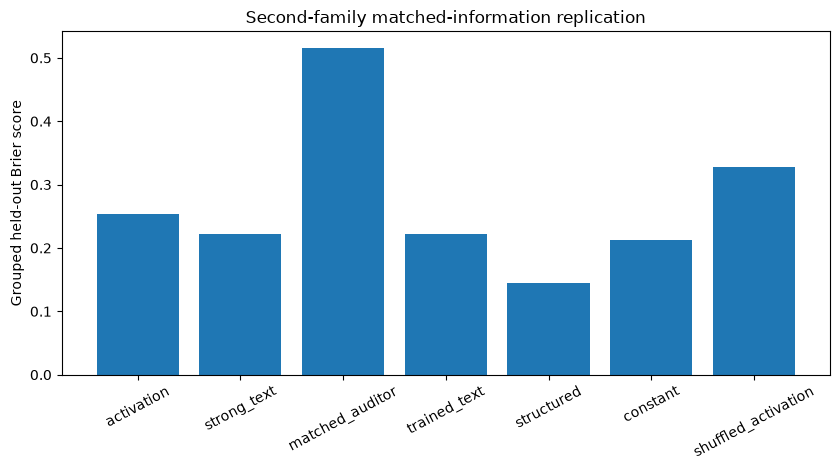

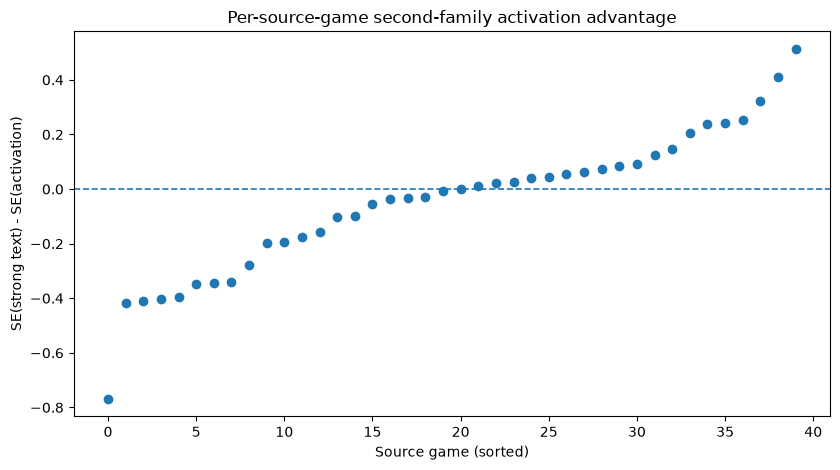

In [15]:
import matplotlib.pyplot as plt
fig,ax=plt.subplots(figsize=(8.5,4.8)); ax.bar(methods,[metrics[m]["brier"] for m in methods]); ax.set_ylabel("Grouped held-out Brier score"); ax.set_title("Second-family matched-information replication"); ax.tick_params(axis="x",rotation=28); fig.tight_layout(); fig.savefig(FIGURE_DIR/"method_brier.png",dpi=180); plt.show()
fig,ax=plt.subplots(figsize=(8.5,4.8)); ordered=game_delta.sort_values("delta_latent").reset_index(drop=True); ax.scatter(np.arange(len(ordered)),ordered.delta_latent); ax.axhline(0,ls="--",lw=1.2); ax.set_xlabel("Source game (sorted)"); ax.set_ylabel("SE(strong text) - SE(activation)"); ax.set_title("Per-source-game second-family activation advantage"); fig.tight_layout(); fig.savefig(FIGURE_DIR/"source_game_deltas.png",dpi=180); plt.show()


## 15. Freeze manifest and archive


In [16]:
final_readiness={**readiness,"activation_beats_shuffled_label_control":bool(activation_beats_shuffle),"all_heldout_predictions_complete":bool(len(pred_df)==len(valid_df)),"privileged_access_supported":bool(h1_supported)}
(TABLE_DIR/"readiness.json").write_text(json.dumps(final_readiness,indent=2))
summary={"notebook_build":NOTEBOOK_BUILD,"run_id":RUN_ID,"source_qwen_run":str(SOURCE_RUN_DIR),"frozen_state_bank_sha256":bank_sha,
         "subject_model":SUBJECT_MODEL,"subject_revision_requested":SUBJECT_REVISION,"subject_revision_resolved":SUBJECT_REVISION_RESOLVED,
         "decoder_layer_path":DECODER_LAYER_PATH,"protocol":protocol,"readiness":final_readiness,"result":result,"cross_model_descriptive":comparison,
         "claim_boundary":"This is a second-model-family replication on the same frozen states. It tests linear final-token residual readers, not all possible neural decoders."}
(TABLE_DIR/"result_summary.json").write_text(json.dumps(summary,indent=2))
manifest={"run_dir":str(RUN_DIR),"protocol":str(MANIFEST_DIR/"protocol_freeze.json"),"source_run":str(SOURCE_RUN_DIR),"records":str(records_jsonl),"activations":str(ACTIVATION_DIR/"pre_action_all_layers.safetensors"),"predictions":str(TABLE_DIR/"heldout_predictions.csv"),"result":str(TABLE_DIR/"replication_result.json"),"figures":sorted(str(p) for p in FIGURE_DIR.glob("*.png"))}
(MANIFEST_DIR/"p1_manifest.json").write_text(json.dumps(manifest,indent=2))
checks=[]
for p in sorted(RUN_DIR.rglob("*")):
    if p.is_file(): checks.append({"path":str(p.relative_to(RUN_DIR)),"bytes":p.stat().st_size,"sha256":hashlib.sha256(p.read_bytes()).hexdigest()})
(RUN_DIR/"checksums.json").write_text(json.dumps(checks,indent=2))
archive=PROJECT_ROOT/f"20_second_model_family_matched_information_{RUN_ID}.zip"
with zipfile.ZipFile(archive,"w",compression=zipfile.ZIP_DEFLATED) as zf:
    for p in sorted(RUN_DIR.rglob("*")):
        if p.is_file(): zf.write(p,arcname=str(Path(NOTEBOOK_SLUG)/RUN_ID/p.relative_to(RUN_DIR)))
print(json.dumps(summary,indent=2)); print("Archive:",archive)
try: del model; torch.cuda.empty_cache()
except Exception: pass


{
  "notebook_build": "latent-reservations-p1-second-model-family-matched-information-v1",
  "run_id": "20260816T085737Z",
  "source_qwen_run": "/workspace/latent-reservations/notebook_outputs/19_cicero_h1_activation_vs_strong_text/20260815T180359Z",
  "frozen_state_bank_sha256": "e21a88ae614279e2bde67554e8f788d28a7c6891b1ffb5cfd281a3bc23280900",
  "subject_model": "mistralai/Mistral-7B-Instruct-v0.3",
  "subject_revision_requested": "main",
  "subject_revision_resolved": "c170c708c41dac9275d15a8fff4eca08d52bab71",
  "decoder_layer_path": "model.layers",
  "protocol": {
    "experiment": "second-model-family replication",
    "source_state_bank_sha256": "e21a88ae614279e2bde67554e8f788d28a7c6891b1ffb5cfd281a3bc23280900",
    "source_state_count": 78,
    "source_games": 40,
    "subject_model": "mistralai/Mistral-7B-Instruct-v0.3",
    "subject_revision_requested": "main",
    "behavioral_target": "model-specific consequential choice of frozen option B versus option A",
    "prompt_form